In [1]:
import sys
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration du chemin racine (Root)
cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
sys.path.append(str(project_root / "src"))

# 2. Imports PINKCC
from pinkcc_ct_seg.data.dataset import BrainMRIDataset
from pinkcc_ct_seg.data.loaders import make_loaders
from pinkcc_ct_seg.models.resnet18 import build_resnet18
from pinkcc_ct_seg.training.engine import validate_one_epoch
from pinkcc_ct_seg.evaluation.metrics import compute_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Évaluation sur : {device}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Chemin vers le dossier Testing
test_dir = project_root / "data" / "raw" / "brain_mri" / "Testing"

# Chargement du dataset de test
test_dataset = BrainMRIDataset(test_dir)

# Création du DataLoader (on utilise make_loaders sans sampler pondéré pour le test)
_, test_loader = make_loaders(
    test_dataset, 
    test_dataset, 
    batch_size=32, 
    weighted=False
)

print(f" Prêt pour l'inférence sur {len(test_dataset)} images de test.")

 Prêt pour l'inférence sur 394 images de test.



 --- RAPPORT DE CLASSIFICATION FINAL --- 
              precision    recall  f1-score   support

           0     0.6273    0.9619    0.7594       105
           1     0.9828    0.7924    0.8774       289

    accuracy                         0.8376       394
   macro avg     0.8051    0.8771    0.8184       394
weighted avg     0.8881    0.8376    0.8459       394



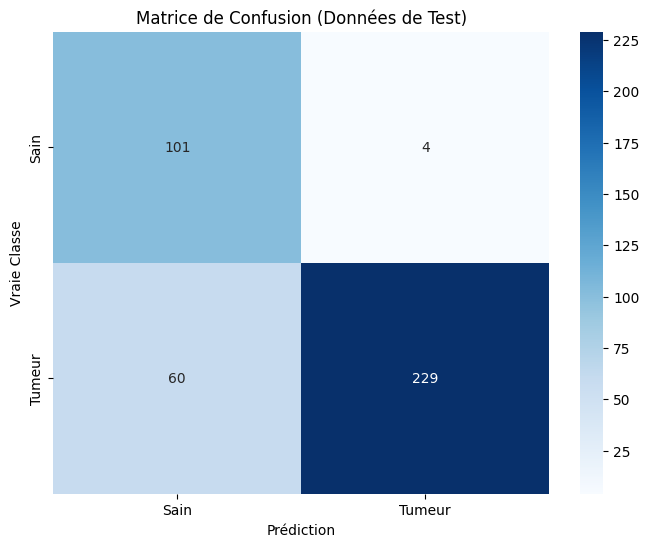

In [ ]:
# 1. Charger le modèle sauvegardé
model_path = project_root / "models" / "best_resnet18_methodB_advanced.pt"
model = build_resnet18(num_classes=2, pretrained=False).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

# 2. Inférence finale
results = validate_one_epoch(model, test_loader, nn.CrossEntropyLoss(), device)
metrics = compute_metrics(y_true=results["targets"], y_pred=results["preds"])

# 3. Affichage visuel
print("\n --- RAPPORT DE CLASSIFICATION FINAL --- ")
print(metrics["classification_report"])

plt.figure(figsize=(8, 6))
sns.heatmap(metrics["confusion_matrix"], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain', 'Tumeur'], yticklabels=['Sain', 'Tumeur'])
plt.title("Matrice de Confusion (Données de Test)")
plt.ylabel('Vraie Classe')
plt.xlabel('Prédiction')
plt.show()